# Daisyworld: динамика численности

На горизонте 1000 шагов прослеживаются обе популяции и момент их исчезновения.

## Расчёт базового опыта

In [1]:
using DrWatson
@quickactivate "DaisyworldLab"
include(srcdir("experiment_tools.jl"))

model = create_world(solar_luminosity=1.0, seed=165)
trajectory = save_history(history_frame(model, 1000), "daisyworld-count")

Row,time,black,white,total,empty,temperature,luminosity,albedo,regulation_error
,Int64,Int64,Int64,Int64,Int64,Float64,Float64,Float64,Float64
1,0,180,180,360,540,16.9135,1.0,0.44,5.58646
2,1,392,242,634,266,25.5179,1.0,0.428778,3.01794
3,2,446,360,806,94,29.4005,1.0,0.465667,6.90047
4,3,456,423,879,21,27.7183,1.0,0.4885,5.2183
5,4,461,438,899,1,24.8571,1.0,0.4935,2.3571
6,5,457,440,897,3,23.0331,1.0,0.494944,0.533051
7,6,460,439,899,1,22.0153,1.0,0.494056,0.484713
8,7,460,440,900,0,21.5064,1.0,0.494444,0.993595
9,8,460,439,899,1,21.252,1.0,0.494056,1.24804


## График и сводка

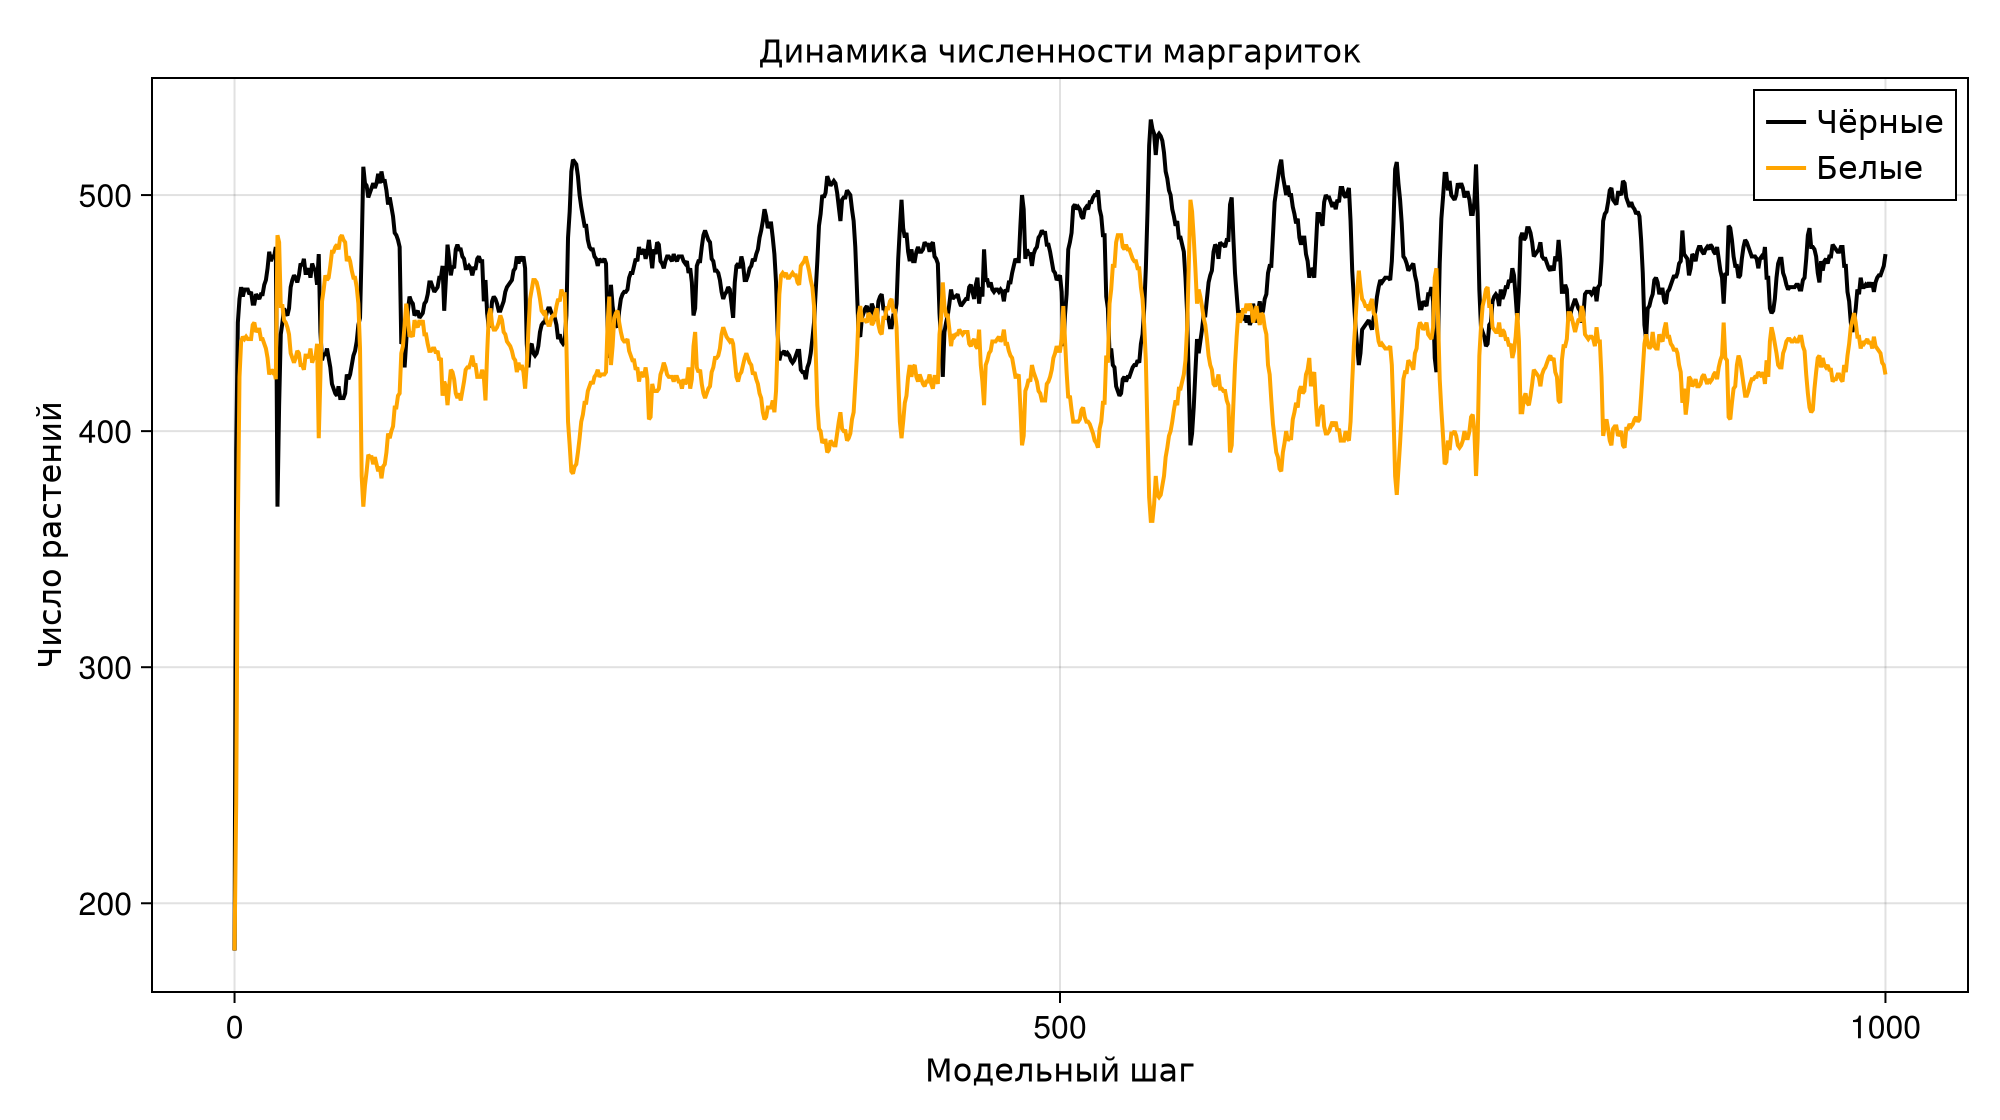

Row,final_black,final_white,peak_black,peak_white,extinction_step
,Int64,Int64,Int64,Int64,Missing
1,475,424,532,498,missing


In [2]:
fig = count_figure(trajectory)
save_figure(fig, "daisyworld-count", "population-dynamics.png";
            report_name="baseline-population-dynamics.png")
display(fig)
summary = DataFrame([(
    final_black=last(trajectory.black),
    final_white=last(trajectory.white),
    peak_black=maximum(trajectory.black),
    peak_white=maximum(trajectory.white),
    extinction_step=extinction_time(trajectory),
)])
CSV.write(scenario_data("daisyworld-count", "summary.csv"), summary)
summary